# Case 5

# Is LSTM-VAE more resilient to strong KL regularisation than MLP-VAE?

## Purpose of this notebook

This notebook demonstrates one of the thesis observations:

> The KL weight (beta) controls how strongly the latent code is pushed toward the prior — too high a weight can starve the latent code of information. Not every architecture is affected equally: the thesis found LSTM-VAE stays comparatively stable as beta increases, while MLP-VAE's detection performance drops.

The thesis studies anomaly detection in streaming ERA5 weather data. It compares the impact of different configurations (VAE architecture, streaming and feature manipulation methods, KL regularisation strength) on VAEs with different deep learning models as encoder/decoder.

This testcase focuses on **contextual anomalies** (locally-plausible values that are abnormal for the season) and two architectures, **MLP-VAE** and **LSTM-VAE**, evaluated at three KL weights.

---

For the complete experiment definitions, consult the thesis section associated with **4.3.3 Effects of KL Regularisation**, together with the YAML configuration files used by this suite.

## What is being compared?

The notebook runs six variants — two architectures, each at three KL weights (`training.elbo_beta`):

| Variant | Beta | Meaning |
|---|---:|---|
| **MLP-VAE** | 0.1 | Weak KL pressure — the latent code is barely constrained toward the prior. |
| **MLP-VAE** | 1.0 | Standard KL weight. |
| **MLP-VAE** | 3.0 | Strong KL pressure — the latent code is pushed hard toward the prior, at risk of losing information. |
| **LSTM-VAE** | 0.1 | Weak KL pressure. |
| **LSTM-VAE** | 1.0 | Standard KL weight. |
| **LSTM-VAE** | 3.0 | Strong KL pressure. |

MLP-VAE and LSTM-VAE differ in how they reconstruct from the latent code — the comparison below tests whether that difference translates into different sensitivity to beta.

## Findings being illustrated

The thesis found that LSTM-VAE remains comparatively stable as beta increases, while MLP-VAE's detection performance drops as beta grows from weak to strong.

This reduced notebook uses the full-scale ERA5 export by default (see `case01_clean_baseline.ipynb` for why), so results should be directionally close to the thesis, though exact metric values are not expected to match (single seed, this repo's own port of the training code). The important result is the **relative pattern**: MLP-VAE's F1 should fall noticeably from beta=0.1 to beta=3.0, while LSTM-VAE's F1 should stay stable across the same range.

The thesis's own treatment of this effect (section 4.3.3) is broader than this notebook — it also covers free-bits (a separate, related regularisation mechanism this notebook does not sweep) and all four architectures across multiple anomaly types. This notebook is a focused, two-architecture reproduction of the core beta-resilience finding.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the six beta variants on the same contextual-anomaly dataset.
4. Collect F1, AUC, precision, recall, and confusion-matrix counts.
5. Plot F1 as a function of beta, split by architecture.

### Expected runtime

Window-based runs use the GPU when available. All six variants share the same dataset; MLP-VAE runs are typically faster than LSTM-VAE.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [9]:
%matplotlib inline
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.10.0+cu126
CUDA available: True
Selected device: Quadro RTX 6000


### Import and/or load Repo

In [10]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: .
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### Step 1 — Configure the run

In [11]:
import os
import yaml

CASE_ID = "case05_kl_regularisation"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

# Edit this directly — works the same locally and on Colab:
#   "full_split_files" (default) -> anom_types/contextual.yaml's own default —
#                      full-scale contextual data, pre-split into a
#                      warmup-only file (shared with case01 — the warmup
#                      portion is anomaly-free and identical regardless of
#                      anomaly type) and a test-only file with the
#                      contextual anomalies injected. Committed to the repo.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice (~50% of full-scale).
#                      Committed to the repo.
#   "mini_28pct"    -> the in-repo 210,384-row ERA5 slice (~28% of full-scale).
#                      Committed to the repo.
DATA_SOURCE = "full_split_files"

_DATA_SOURCE_LAYERS = {
    "full_split_files": None,   # anom_types/contextual.yaml's own default — no extra layer needed
    "mini_50pct": "../../modules/data_source/mini_50pct_contextual.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_contextual.yaml",
}

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_data_source_layer = _DATA_SOURCE_LAYERS[DATA_SOURCE]

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")

DATA_SOURCE = 'full_split_files' -> None


#### Configuration file

The notebooks test suites combines a shared ERA5 configuration (`modules/era5_common.yaml`) with the architecture, anomaly type, stream mode, and beta settings for each run.

`DATA_SOURCE` may be configured to choose other datasets from the era5 data directory.
The default is `"full_split_files"`, which is the full-scale contextual-anomaly data, where warmup and test files are split (`data/era5/full_scale/split/era5_clean_warmup.csv` and `data/era5/full_scale/split/era5_contextual_test.csv`).

All variants use the same base configuration and evaluation procedure. The intended comparison is therefore the effect of **KL weight (beta)** on each architecture's contextual-anomaly detection.

#### Output Directory

During execution, the script creates a separate run directory in the repo for each variant under `OUTPUT_DIR` (`runs/regression/case05_kl_regularisation` by default).

`notebooks/cases/case05_kl_regularisation_suite.yaml` layers `modules/era5_common.yaml` with the architecture / anomaly-type / stream-mode fragments and the per-run beta override (see the suite file for the exact overrides).

### Step 2 Run the testsuite

### Command:

In [12]:
!python run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR} --skip-existing

[suite] log     : runs/regression/suite.log
[suite] suite   : runs/regression/case05_kl_regularisation/case05_kl_regularisation_suite_resolved.yaml
[suite] session : runs/regression
[suite] base cfg: modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1, 2]  (3 slot(s))
[suite] 6 run(s) planned:
  [  1] MLP_beta_0_1  [case05_kl_regularisation/case05_kl_regularisation_suite_resolved]  (module: regression.run_trial)
  [  2] MLP_beta_1_0  [case05_kl_regularisation/case05_kl_regularisation_suite_resolved]  (module: regression.run_trial)
  [  3] MLP_beta_3_0  [case05_kl_regularisation/case05_kl_regularisation_suite_resolved]  (module: regression.run_trial)
  [  4] LSTM_beta_0_1  [case05_kl_regularisation/case05_kl_regularisation_suite_resolved]  (module: regression.run_trial)
  [  5] LSTM_beta_1_0  [case05_kl_regularisation/case05_kl_regularisation_suite_resolved]  (module: regression.run_trial)
  [  6] LSTM_beta_3_0  [case05_kl_regularisation/case05_kl_reg

### Step 3 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms
- an F1 comparison across variants
- confusion-matrix summaries
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [13]:
!python cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case05_kl_regularisation
[cross] output  : runs/regression/case05_kl_regularisation/cross_compare
[cross] 6 run(s) found:
  LSTM_Contextual_0.1                                 arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  LSTM_Contextual_1.0                                 arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  LSTM_Contextual_3.0                                 arch=LSTM  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_0.1                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_1.0                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window
  MLP_Contextual_3.0                                  arch=MLP  anomaly=Contextual  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Contextual_0.1 ... ok
  LSTM_Contextual_1.0 ... ok
  LSTM_Contextual_3.0 ... ok
  MLP_Contextual_0.1 ... ok
  MLP_Contextual_1.0 ... ok
  MLP_Co

### Step 4 — Quantitative Results

### Command:

In [14]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

perf["variant"] = perf["variant"].astype(float)

print("Comparison of beta variants")
display(
    perf[columns]
    .sort_values(["arch", "variant"])
    .reset_index(drop=True)
    .style.format({
        "f1": "{:.3f}",
        "auc": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
    })
)

Comparison of beta variants


,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,LSTM_Contextual_0.1,LSTM,Contextual,0.100000,0.474,0.940,0.337,0.798,700,1378,177
1,LSTM_Contextual_1.0,LSTM,Contextual,1.000000,0.658,0.941,0.767,0.577,506,154,371
2,LSTM_Contextual_3.0,LSTM,Contextual,3.000000,0.536,0.906,0.746,0.418,367,125,510
3,MLP_Contextual_0.1,MLP,Contextual,0.100000,0.618,0.936,0.602,0.635,557,369,320
4,MLP_Contextual_1.0,MLP,Contextual,1.000000,0.277,0.837,0.547,0.186,163,135,714
5,MLP_Contextual_3.0,MLP,Contextual,3.000000,0.055,0.692,0.207,0.032,28,107,849


#### Expected pattern

```text
MLP-VAE:  F1(beta=0.1)  >  F1(beta=1.0)  >  F1(beta=3.0)     (falling as beta rises)
LSTM-VAE: F1(beta=0.1)  ~=  F1(beta=1.0)  ~=  F1(beta=3.0)    (comparatively flat)
```

The testcase is successful when MLP-VAE shows a clear F1 decline from beta=0.1 to beta=3.0 while LSTM-VAE stays comparatively flat, even if the exact values differ from the thesis.

### Step 5 — Qualitative support (Plots)

#### F1 vs. beta

##### Command:

F1 vs beta, split by architecture:


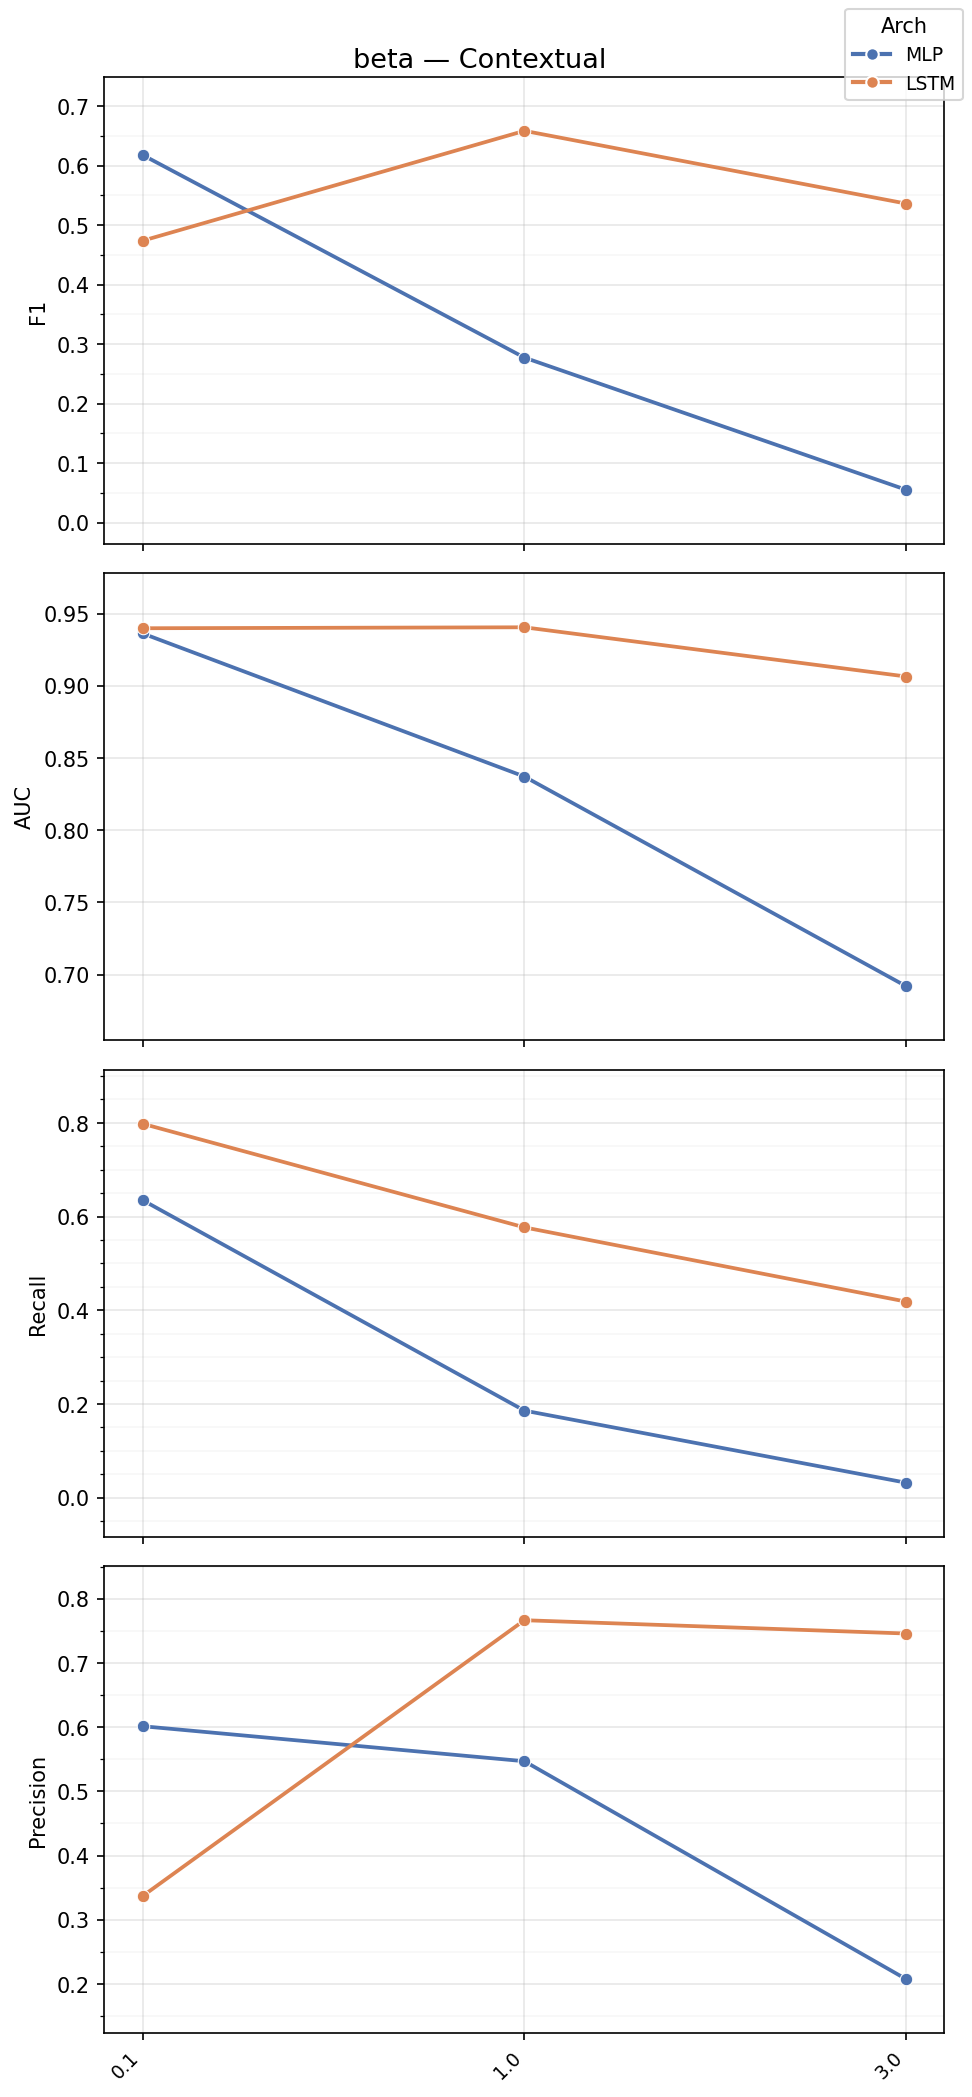

In [15]:
# Display the key comparison plot(s) inline
import glob
from IPython.display import Image, display

print("F1 vs beta, split by architecture:")
for p in sorted(glob.glob(f"{OUTPUT_DIR}/cross_compare/contextual/section_lines_beta.png")):
    display(Image(filename=p))

Plots F1 against beta (0.1, 1.0, 3.0) as two lines, one per architecture. MLP-VAE's line should decline as beta rises; LSTM-VAE's line should stay comparatively flat.

#### The plot can indicate, among other things:

1. Whether MLP-VAE's F1 falls meaningfully as beta grows from 0.1 to 3.0.
2. Whether LSTM-VAE's F1 is comparatively insensitive to beta across the same range.
3. At what beta value (if any) the models' F1 collapses or peaks.
4. Determine the tradeoff between Recall and Precision

### Main takeaway

LSTM-VAE and MLP-VAE are not equally sensitive to strong KL regularisation: MLP-VAE's detection performance drops as beta rises, while LSTM-VAE stays comparatively stable across the same range.

## Scope of this testcase

This notebook is a compact demonstration, not a full reproduction of every KL-regularisation experiment reported in the thesis. With `DATA_SOURCE = "full_split_files"` (the default) it runs on the full-scale contextual-anomaly data. With `DATA_SOURCE = "mini_50pct"` / `"mini_28pct"` a shorter ERA5 interval is used instead — useful for a quick check, but see `case01_clean_baseline.ipynb` for why it can give different results than the full-scale data.

The thesis's own treatment of this effect is broader than this notebook: it covers all four architectures, sweeps free-bits (a separate regularisation mechanism this notebook does not touch) in addition to beta, and evaluates across multiple anomaly types. This notebook is a focused, two-architecture reproduction of the core beta-resilience finding.

Conclusions should be based on the **direction and consistency of the F1-vs-beta trend per architecture**, rather than exact numerical agreement with the thesis figures (single seed, this repo's own port of the training code).